# Cruzamento Espacial do Voto (VAA) - Perfil Individual

Neste notebook, aplicamos a Teoria Espacial do Voto de Anthony Downs (1957) para um **único eleitor**.
Você insere as respostas do eleitor e o algoritmo mapeia a proximidade dele com os pré-candidatos, gerando a recomendação (Bússola Eleitoral) baseada na distância matemática e na similaridade de perfil.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.decomposition import PCA
import ipywidgets as widgets
from IPython.display import display, HTML

sns.set_theme(style='whitegrid')

## 1. O Perfil dos Pré-Candidatos (Gabarito)
Convertemos as posições públicas de candidatos em coordenadas nos nossos blocos D (Economia) e E (Valores).


In [2]:
partidos_data = {
    'Partido': ['PT', 'PL', 'NOVO', 'PDT'],
    'ideologia': ['Social-Democracia', 'Centrão/Fisiológico', 'Liberalismo Clássico', 'Trabalhismo'],
    'justificativa': ['Partido de massas com foco no estado de bem-estar social', 'Foco na governabilidade', 'Foco em desregulamentação e estado mínimo', 'Defesa da indústria nacional e do trabalhador'],
    'bloco_d_estatais': [2, 4, 5, 2],
    'bloco_d_tabelamento': [3, 2, 1, 3],
    'bloco_e_punitivismo': [2, 4, 3, 3],
    'bloco_e_educacao': [2, 4, 3, 2],
    'bloco_g_corrupcao': [2, 4, 5, 2],
    'bloco_g_pesquisa': [4, 2, 1, 5],
    'bloco_g_politica_externa': [4, 2, 1, 4]
}
df_partidos = pd.DataFrame(partidos_data).set_index('Partido')

politicos_data = {
    'Político': ['Lula', 'Flavio Bolsonaro', 'Romeu Zema', 'Ciro Gomes'],
    'ideologia': ['Pragmatismo Progressista', 'Direita Radical', 'Neoliberalismo', 'Nacional-Desenvolvimentismo'],
    'justificativa': ['Conciliação de classes e pautas sociais', 'Pauta de costumes conservadora e punitivismo', 'Livre mercado estrito e alianças de conveniência', 'Estado forte na economia e crítica ao rentismo'],
    'bloco_d_estatais': [1, 5, 5, 2],
    'bloco_d_tabelamento': [4, 1, 1, 3],
    'bloco_e_punitivismo': [2, 5, 4, 3],
    'bloco_e_educacao': [2, 5, 4, 2],
    'bloco_g_corrupcao': [1, 5, 5, 2],
    'bloco_g_pesquisa': [5, 1, 2, 5],
    'bloco_g_politica_externa': [5, 1, 2, 4]
}
df_politicos = pd.DataFrame(politicos_data).set_index('Político')

cols_opiniao = ['bloco_d_estatais', 'bloco_d_tabelamento', 'bloco_e_punitivismo', 'bloco_e_educacao', 'bloco_g_corrupcao', 'bloco_g_pesquisa', 'bloco_g_politica_externa']

display(HTML('<h3>Gabarito dos Partidos</h3>'))
display(df_partidos)
display(HTML('<h3>Gabarito dos Políticos</h3>'))
display(df_politicos)

,ideologia,justificativa,bloco_d_estatais,bloco_d_tabelamento,bloco_e_punitivismo,bloco_e_educacao,bloco_g_corrupcao,bloco_g_pesquisa,bloco_g_politica_externa
Partido,,,,,,,,,
PT,Social-Democracia,Partido de massas com foco no estado de bem-es...,2,3,2,2,2,4,4
PL,Centrão/Fisiológico,Foco na governabilidade,4,2,4,4,4,2,2
NOVO,Liberalismo Clássico,Foco em desregulamentação e estado mínimo,5,1,3,3,5,1,1
PDT,Trabalhismo,Defesa da indústria nacional e do trabalhador,2,3,3,2,2,5,4


,ideologia,justificativa,bloco_d_estatais,bloco_d_tabelamento,bloco_e_punitivismo,bloco_e_educacao,bloco_g_corrupcao,bloco_g_pesquisa,bloco_g_politica_externa
Político,,,,,,,,,
Lula,Pragmatismo Progressista,Conciliação de classes e pautas sociais,1,4,2,2,1,5,5
Flavio Bolsonaro,Direita Radical,Pauta de costumes conservadora e punitivismo,5,1,5,5,5,1,1
Romeu Zema,Neoliberalismo,Livre mercado estrito e alianças de conveniência,5,1,4,4,5,2,2
Ciro Gomes,Nacional-Desenvolvimentismo,Estado forte na economia e crítica ao rentismo,2,3,3,2,2,5,4


## 2. Formulário Interativo do Eleitor
Preencha o formulário completo (Blocos A a F) para definir o perfil sociodemográfico e ideológico do eleitor.


In [3]:
# Criação dos widgets interativos
style = {'description_width': 'initial'}

nome_widget = widgets.Text(value='Eleitor Exemplo', description='Nome:', style=style)

display(HTML('<h3>Bloco A - Demografia e Clivagens Sociais</h3>'))
idade_widget = widgets.IntText(value=30, description='Idade:', style=style)
renda_widget = widgets.Dropdown(options=['Até 2 salários mínimos', '2 a 5 salários mínimos', 'Mais de 5 salários mínimos'], description='Faixa de Renda:', style=style)
escolaridade_widget = widgets.Dropdown(options=['Ensino Fundamental', 'Ensino Médio', 'Ensino Superior'], description='Escolaridade:', style=style)
regiao_widget = widgets.Dropdown(options=['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul'], description='Região:', style=style)
religiao_widget = widgets.Dropdown(options=['Católica', 'Evangélica', 'Outra', 'Sem Religião'], description='Religião:', style=style)
beneficio_widget = widgets.Dropdown(options=['Sim', 'Não'], description='Recebe Benefício Social?', style=style)

display(HTML('<h3>Bloco B - Capital Cultural</h3>'))
informacao_widget = widgets.Dropdown(options=['TV Aberta', 'Redes Sociais (Instagram/TikTok)', 'Aplicativos de Mensagem (WhatsApp/Telegram)', 'Mídia Independente', 'Rádio'], description='Principal Fonte de Informação:', style=style)

display(HTML('<h3>Bloco C - Matriz de Valores</h3>'))
prioridade_widget = widgets.Dropdown(options=['Controle da Inflação', 'Geração de Empregos', 'Combate ao Crime Violento', 'Preservação Ambiental', 'Combate às Desigualdades', 'Defesa da Família Tradicional', 'Liberdade de Expressão'], description='Prioridade Absoluta:', style=style)

display(HTML('<h3>Bloco D - Economia (Eixo X)</h3>'))
estatais_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Privatização de Estatais (1=Estado Forte, 5=Privatização Total):',
    style=style, layout=widgets.Layout(width='80%')
)
tabelamento_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Controle de Preços (1=Livre Mercado, 5=Intervenção Estatal):',
    style=style, layout=widgets.Layout(width='80%')
)

display(HTML('<h3>Bloco E - Valores e Moral (Eixo Y)</h3>'))
punitivismo_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Segurança Pública (1=Ressocialização, 5=Punição Severa):',
    style=style, layout=widgets.Layout(width='80%')
)
educacao_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Educação (1=Progressista, 5=Conservadora):',
    style=style, layout=widgets.Layout(width='80%')
)

display(HTML('<h3>Bloco G - Temas Emergentes</h3>'))
corrupcao_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Corrupção (1=Sistêmica, 5=Punitiva):',
    style=style, layout=widgets.Layout(width='80%')
)
pesquisa_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Pesquisa (1=Privada, 5=Estado):',
    style=style, layout=widgets.Layout(width='80%')
)
politica_externa_widget = widgets.IntSlider(
    value=3, min=1, max=5, step=1,
    description='Pol. Externa (1=EUA/Ocid., 5=Sul Global):',
    style=style, layout=widgets.Layout(width='80%')
)

display(HTML('<h3>Bloco F - Decisão e Polarização</h3>'))
opcoes_rejeicao = ['Nenhum'] + list(df_politicos.index)
rejeicao_widget = widgets.Dropdown(
    options=opcoes_rejeicao,
    value='Nenhum',
    description='Rejeição Absoluta (Não votaria de jeito nenhum):',
    style=style, layout=widgets.Layout(width='50%')
)

# Agrupando e exibindo o formulário completo
form = widgets.VBox([
    nome_widget, widgets.HTML('<hr>'),
    idade_widget, renda_widget, escolaridade_widget, regiao_widget, religiao_widget, beneficio_widget, widgets.HTML('<hr>'),
    informacao_widget, widgets.HTML('<hr>'),
    prioridade_widget, widgets.HTML('<hr>'),
    estatais_widget, tabelamento_widget, widgets.HTML('<hr>'),
    punitivismo_widget, educacao_widget, widgets.HTML('<hr>'),
    corrupcao_widget, pesquisa_widget, politica_externa_widget, widgets.HTML('<hr>'),
    rejeicao_widget
])
display(form)

## 3. O Motor VAA: Calculando Proximidade e Afastamento
O algoritmo captura as respostas do formulário acima, calcula a Distância Euclidiana baseada nas coordenadas ideológicas e aplica a penalidade caso exista Rejeição Absoluta.

*Execute esta célula APÓS preencher o formulário acima.*


In [4]:
# Lendo os valores do formulário interativo
eleitor_nome = nome_widget.value
estatais = estatais_widget.value
tabelamento = tabelamento_widget.value
punitivismo = punitivismo_widget.value
educacao = educacao_widget.value
corrupcao = corrupcao_widget.value
pesquisa = pesquisa_widget.value
politica_externa = politica_externa_widget.value
rejeicao_absoluta = rejeicao_widget.value

vetor_eleitor = np.array([[estatais, tabelamento, punitivismo, educacao, corrupcao, pesquisa, politica_externa]])
print(f"Perfil capturado do Eleitor '{eleitor_nome}': {vetor_eleitor[0]}\n")

print(f"Demografia: {idade_widget.value} anos, {regiao_widget.value}, {renda_widget.value}, Benefício: {beneficio_widget.value}")
print(f"Valores: {prioridade_widget.value} | Informação: {informacao_widget.value}\n")

vetores_partidos = df_partidos[cols_opiniao].values
vetores_politicos = df_politicos[cols_opiniao].values

# --- Distância Euclidiana ---
dist_partidos = euclidean_distances(vetor_eleitor, vetores_partidos)[0]
dist_politicos = euclidean_distances(vetor_eleitor, vetores_politicos)[0]

res_partidos = pd.DataFrame({'Partido': df_partidos.index, 'Distancia': dist_partidos}).sort_values(by='Distancia').reset_index(drop=True)
res_politicos = pd.DataFrame({'Político': df_politicos.index, 'Distancia': dist_politicos})

# Aplicar filtro de Veto por Polarização Afetiva (Rejeição Absoluta) apenas para político
res_politicos['Veto_Aplicado'] = res_politicos['Político'].apply(lambda x: True if x == rejeicao_absoluta else False)
res_politicos.loc[res_politicos['Veto_Aplicado'] == True, 'Distancia'] = np.inf
res_politicos = res_politicos.sort_values(by='Distancia').reset_index(drop=True)

print(f">>> RESULTADO DA BÚSSOLA ELEITORAL PARA: {eleitor_nome} <<<")
cand_ideal = res_politicos.iloc[0]['Político']
part_ideal = res_partidos.iloc[0]['Partido']
if res_politicos.iloc[0]['Distancia'] == np.inf:
    print("\nO eleitor rejeitou absolutamente todos os candidatos ou ocorreu um erro no cálculo.")
else:
    print(f"\n🏆 **Político Ideal:** {cand_ideal} (Ideologia: {df_politicos.loc[cand_ideal, 'ideologia']})")
    print(f"   *Justificativa:* {df_politicos.loc[cand_ideal, 'justificativa']}")
    print(f"\n🏛️ **Partido Ideal:** {part_ideal} (Ideologia: {df_partidos.loc[part_ideal, 'ideologia']})")
    print(f"   *Justificativa:* {df_partidos.loc[part_ideal, 'justificativa']}")

print("\n--- Análise de Concordâncias e Discordâncias (Político Ideal) ---")
for col in cols_opiniao:
    diff = abs(df_politicos.loc[cand_ideal, col] - eval(col.replace('bloco_d_', '').replace('bloco_e_', '').replace('bloco_g_', '')))
    if diff <= 1:
        print(f"✅ Concordância Forte em: {col}")
    elif diff >= 3:
        print(f"❌ Discordância Forte em: {col}")
    else:
        print(f"⚠️ Alinhamento Parcial em: {col}")

print("\n--- Classificação do Eleitor ---")
media_economia = (estatais + tabelamento) / 2
media_valores = (punitivismo + educacao) / 2
if media_economia < 3 and media_valores < 3:
    perfil = 'Esquerda Progressista'
elif media_economia > 3 and media_valores > 3:
    perfil = 'Direita Conservadora'
elif media_economia > 3 and media_valores < 3:
    perfil = 'Liberalismo/Libertarianismo'
else:
    perfil = 'Centro/Moderado'
print(f"Baseado em seus eixos principais, o algoritmo classifica você com um viés de: **{perfil}**")

Perfil capturado do Eleitor 'Eleitor Exemplo': [3 3 3 3 3 3 3]

Demografia: 30 anos, Norte, Até 2 salários mínimos, Benefício: Sim
Valores: Controle da Inflação | Informação: TV Aberta

>>> RESULTADO DA BÚSSOLA ELEITORAL PARA: Eleitor Exemplo <<<

🏆 **Político Ideal:** Ciro Gomes (Ideologia: Nacional-Desenvolvimentismo)
   *Justificativa:* Estado forte na economia e crítica ao rentismo

🏛️ **Partido Ideal:** PT (Ideologia: Social-Democracia)
   *Justificativa:* Partido de massas com foco no estado de bem-estar social

--- Análise de Concordâncias e Discordâncias (Político Ideal) ---
✅ Concordância Forte em: bloco_d_estatais
✅ Concordância Forte em: bloco_d_tabelamento
✅ Concordância Forte em: bloco_e_punitivismo
✅ Concordância Forte em: bloco_e_educacao
✅ Concordância Forte em: bloco_g_corrupcao
⚠️ Alinhamento Parcial em: bloco_g_pesquisa
✅ Concordância Forte em: bloco_g_politica_externa

--- Classificação do Eleitor ---
Baseado em seus eixos principais, o algoritmo classifica você com

## 4. Visualização 2D (Bússola Eleitoral)
Comprimimos as 4 dimensões de opiniões em 2 usando PCA para que possamos enxergar a posição do eleitor no mapa político.


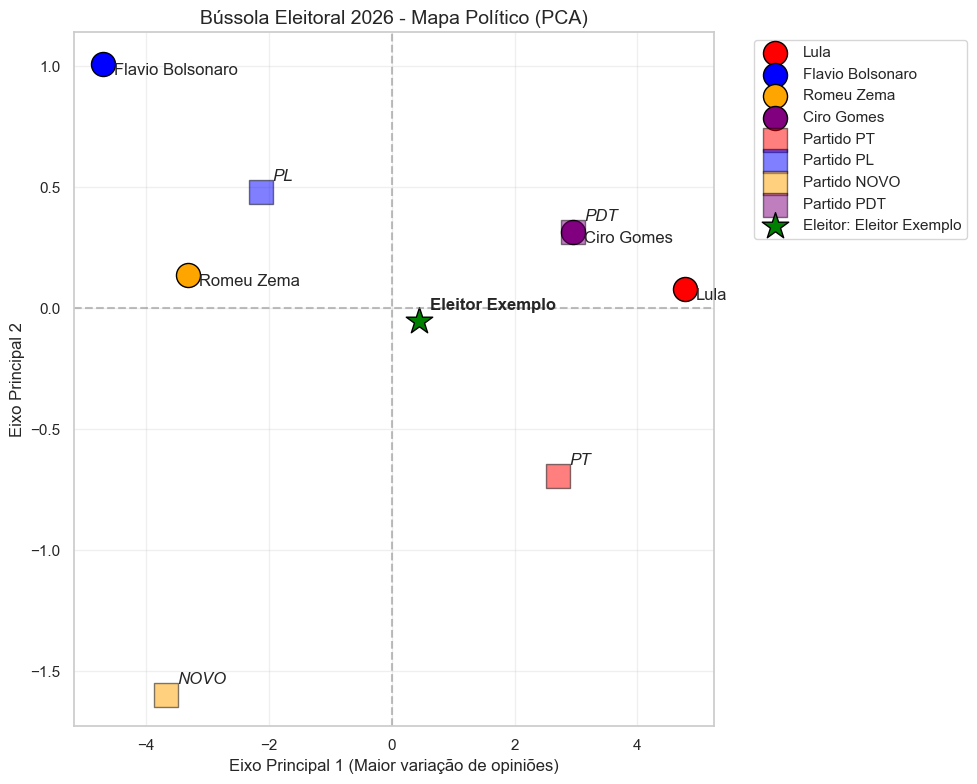

In [5]:
pca = PCA(n_components=2)

# Juntar o eleitor com os candidatos para o mapa
vetores_totais = np.vstack([df_politicos[cols_opiniao].values, df_partidos[cols_opiniao].values, vetor_eleitor])
proj_2d = pca.fit_transform(vetores_totais)

len_pol = len(df_politicos)
len_part = len(df_partidos)
proj_pol = proj_2d[:len_pol]
proj_part = proj_2d[len_pol:len_pol+len_part]
proj_eleit = proj_2d[-1]

plt.figure(figsize=(10, 8))

# Plotar Políticos
cores_pol = ['red', 'blue', 'orange', 'purple']
for i, (idx, row) in enumerate(df_politicos.iterrows()):
    plt.scatter(proj_pol[i, 0], proj_pol[i, 1], color=cores_pol[i], s=300, edgecolors='black', label=idx, marker='o')
    plt.annotate(idx, (proj_pol[i, 0], proj_pol[i, 1]), xytext=(8, -8), textcoords='offset points')

# Plotar Partidos
for i, (idx, row) in enumerate(df_partidos.iterrows()):
    plt.scatter(proj_part[i, 0], proj_part[i, 1], color=cores_pol[i], s=300, edgecolors='black', label=f'Partido {idx}', marker='s', alpha=0.5)
    plt.annotate(idx, (proj_part[i, 0], proj_part[i, 1]), xytext=(8, 8), textcoords='offset points', style='italic')

# Plotar o Eleitor
plt.scatter(proj_eleit[0], proj_eleit[1], color='green', s=400, edgecolors='black', label=f"Eleitor: {eleitor_nome}", marker='*')
plt.annotate(f"{eleitor_nome}", (proj_eleit[0], proj_eleit[1]), xytext=(8, 8), textcoords='offset points', fontweight='bold')

plt.title(f'Bússola Eleitoral 2026 - Mapa Político (PCA)', fontsize=14)
plt.xlabel('Eixo Principal 1 (Maior variação de opiniões)')
plt.ylabel('Eixo Principal 2')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()